In [1]:
# -----------------------------
# CFPB Complaint Data Analysis
# Complete Script for Regression & Preprocessing
# -----------------------------

# 1. Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 2. Load CFPB complaint data in chunks (to save memory)
# -----------------------------
url = "https://files.consumerfinance.gov/ccdb/complaints.csv.zip"

needed_cols = [
    'Date received', 'Date sent to company', 'Product', 'Issue',
    'Company', 'State', 'Submitted via', 'Company response to consumer',
    'Timely response?'
]

chunks = []

for chunk in pd.read_csv(url, compression='zip', usecols=needed_cols, chunksize=300000):

    # Fast string filter first
    chunk = chunk[chunk['Date received'] >= '2017-01-20']

    # Convert after filtering
    chunk['Date received'] = pd.to_datetime(chunk['Date received'])

    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)

print(f"Data loaded: {len(df):,} rows")
print(f"Date range: {df['Date received'].min().date()} to {df['Date received'].max().date()}")



Data loaded: 13,443,074 rows
Date range: 2017-01-20 to 2026-03-25


In [2]:
# -----------------------------
# 3. Compute date similarity for insight (optional)
# -----------------------------
df['Date sent to company'] = pd.to_datetime(df['Date sent to company'])
fraction_similar = ((df['Date received'] == df['Date sent to company']).sum()) / df.shape[0]
print(f"Similarity between date received and date sent to company: {fraction_similar:.2%}")

# -----------------------------
# 4. Encode presidential administrations
# -----------------------------
bins = [
    pd.Timestamp('2009-01-20'),
    pd.Timestamp('2017-01-20'),
    pd.Timestamp('2021-01-20'),
    pd.Timestamp('2025-01-20')
]

labels = ['Trump_One', 'Biden', 'Trump_Two']

df['president_date_received'] = pd.cut(df['Date received'], bins=bins, labels=labels, right=False)
df['president_date_sent_to_company'] = pd.cut(df['Date sent to company'], bins=bins, labels=labels, right=False)

# Remove Obama-era complaints (outside scope)
df = df[df['president_date_received'] != 'Obama']
df = df[df['president_date_sent_to_company'] != 'Obama']



Similarity between date received and date sent to company: 95.15%


In [3]:
# -----------------------------
# 5. Simplify company response outcomes
# -----------------------------
df['response_simple'] = df['Company response to consumer'].replace({
    'Closed with monetary relief': 'Monetary Relief',
    'Closed with non-monetary relief': 'Non-Monetary Relief',
    'Closed': 'No Relief',
    'Closed with explanation': 'Explanation',
    'Closed without relief': 'No Relief',
    'Untimely response': 'No Relief'
})

# Drop rows with missing responses
df.dropna(subset=['response_simple'], inplace=True)

# -----------------------------
# 6. Drop unnecessary columns & clean data
# -----------------------------
cols_with_nas = ['tags', 'consumer_disputed', 'consumer_complaint_narrative',
                 'company_public_response', 'consumer_consent_provided',
                 'subissue', 'subproduct', 'zip_code', 'state']

drop_cols = cols_with_nas + ['Date received', 'Date sent to company']
df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)



In [4]:
# -----------------------------
# 7. Reduce Categories (more aggressively)
# -----------------------------
top_products = df['Product'].value_counts().nlargest(5).index
df['Product'] = df['Product'].where(df['Product'].isin(top_products), 'Other')

top_states = df['State'].value_counts().nlargest(10).index
df['State'] = df['State'].where(df['State'].isin(top_states), 'Other')

top_submit = df['Submitted via'].value_counts().nlargest(3).index
df['Submitted via'] = df['Submitted via'].where(df['Submitted via'].isin(top_submit), 'Other')

# -----------------------------
# 8. One-hot encode features (sparse)
# -----------------------------
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['State', 'Product', 'Submitted via']

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=True,   # updated for modern scikit-learn
    min_frequency=0.01
)

X = encoder.fit_transform(df[categorical_cols])

# Target variable
y = df['response_simple']

print(f"Feature matrix shape: {X.shape}")  # Sparse matrix

Feature matrix shape: (13443053, 21)


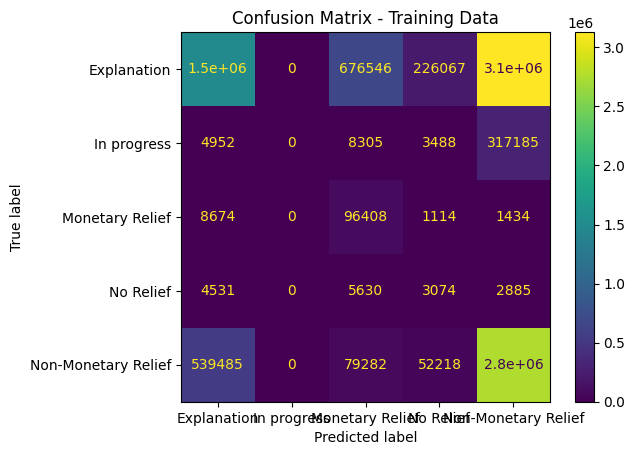

Training Accuracy: 0.46219475869479903
Training Balanced Accuracy: 0.43211842401438183


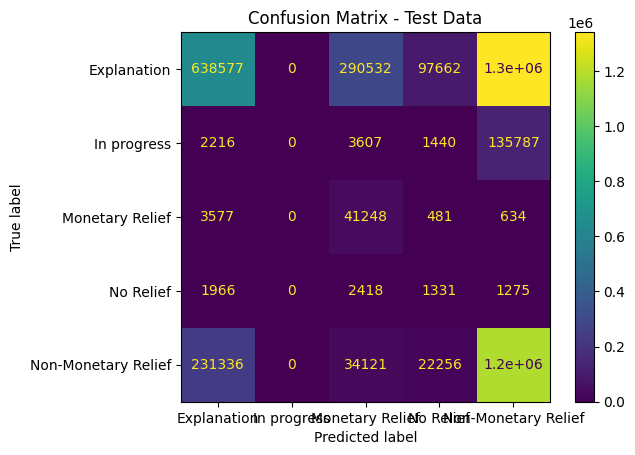

Test Accuracy: 0.4618670460778256
Test Balanced Accuracy: 0.4324316576859662


In [7]:
# -----------------------------
# 9. Train/test split
# -----------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=5
)
# -----------------------------
# 10. Logistic Regression via SGDClassifier with class weights
# -----------------------------
from sklearn.linear_model import SGDClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, balanced_accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute class weights
classes = y_train.unique()
class_weights = dict(zip(
    classes,
    compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
))

# SGDClassifier with log_loss and class weights
lr = SGDClassifier(
    loss='log_loss',   # logistic regression
    max_iter=1000,
    tol=1e-3,          # early stopping tolerance
    n_jobs=-1,         # use all CPU cores
    random_state=5,
    class_weight=class_weights
)

# Fit the model
lr.fit(X_train, y_train)

# -----------------------------
# Training Evaluation
# -----------------------------
pred_train = lr.predict(X_train)

ConfusionMatrixDisplay.from_predictions(y_train, pred_train)
plt.title('Confusion Matrix - Training Data')
plt.show()

print("Training Accuracy:", accuracy_score(y_train, pred_train))
print("Training Balanced Accuracy:", balanced_accuracy_score(y_train, pred_train))

# -----------------------------
# Test Evaluation
# -----------------------------
pred_test = lr.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, pred_test)
plt.title('Confusion Matrix - Test Data')
plt.show()

print("Test Accuracy:", accuracy_score(y_test, pred_test))
print("Test Balanced Accuracy:", balanced_accuracy_score(y_test, pred_test))
